In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### DataFrames

In [23]:
df_1 = pd.read_csv('data\ogd-smn_bou_t_historical_2000-2009.csv', sep=';')
df_2 = pd.read_csv('data\ogd-smn_bou_t_historical_2010-2019.csv', sep=';')
df_3 = pd.read_csv('data\ogd-smn_bou_t_historical_2020-2029.csv', sep=';')

In [24]:
frames = [df_1, df_2, df_3]
df = pd.concat(frames, ignore_index=True)

### Suppression des colonnes ayant plus de 90% de NaN

  station_abbr reference_timestamp  tre200s0  xchills0  ure200s0  tde200s0  \
0          BOU 2004-02-01 00:00:00       NaN       NaN       NaN       NaN   
1          BOU 2004-02-01 00:10:00       NaN       NaN       NaN       NaN   
2          BOU 2004-02-01 00:20:00       NaN       NaN       NaN       NaN   
3          BOU 2004-02-01 00:30:00       NaN       NaN       NaN       NaN   
4          BOU 2004-02-01 00:40:00       NaN       NaN       NaN       NaN   

   pva200s0  prestas0  pp0qnhs0  pp0qffs0  fkl010z1  fve010z0  fkl010z0  \
0       NaN       NaN       NaN       NaN       2.8       1.9       1.9   
1       NaN       NaN       NaN       NaN       3.0       2.2       2.3   
2       NaN       NaN       NaN       NaN       4.0       2.4       2.5   
3       NaN       NaN       NaN       NaN       5.2       3.7       3.8   
4       NaN       NaN       NaN       NaN       4.7       3.2       3.3   

   dkl010z0  fu3010z0  fkl010z3  fu3010z1  fu3010z3  
0     149.0       6.8     

<Axes: >

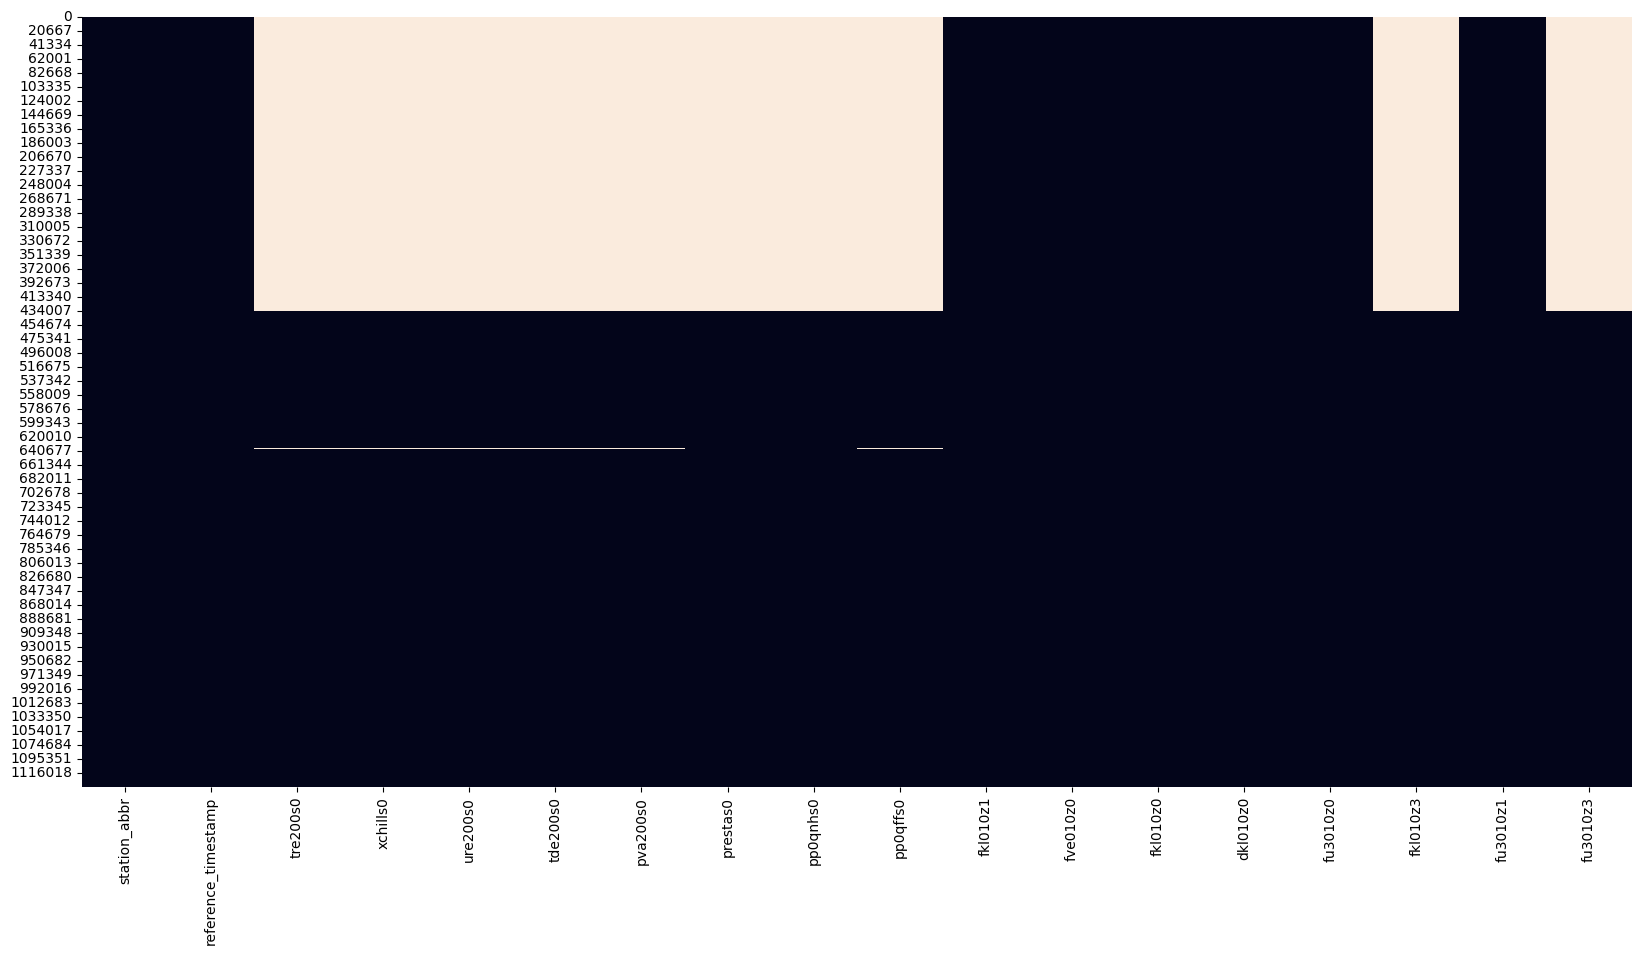

In [40]:
df = df[df.columns[df.isna().sum()/df.shape[0] <0.8]]

print(df.head())

plt.figure(figsize=(20,10))
sns.heatmap(df.isna(), cbar=False)

### Df depuis le moment où toutes le données sont dispo (21.12.2012)

Date de début réelle : 2012-08-21 08:30:00
Nombre de lignes restantes : 702813


<Axes: >

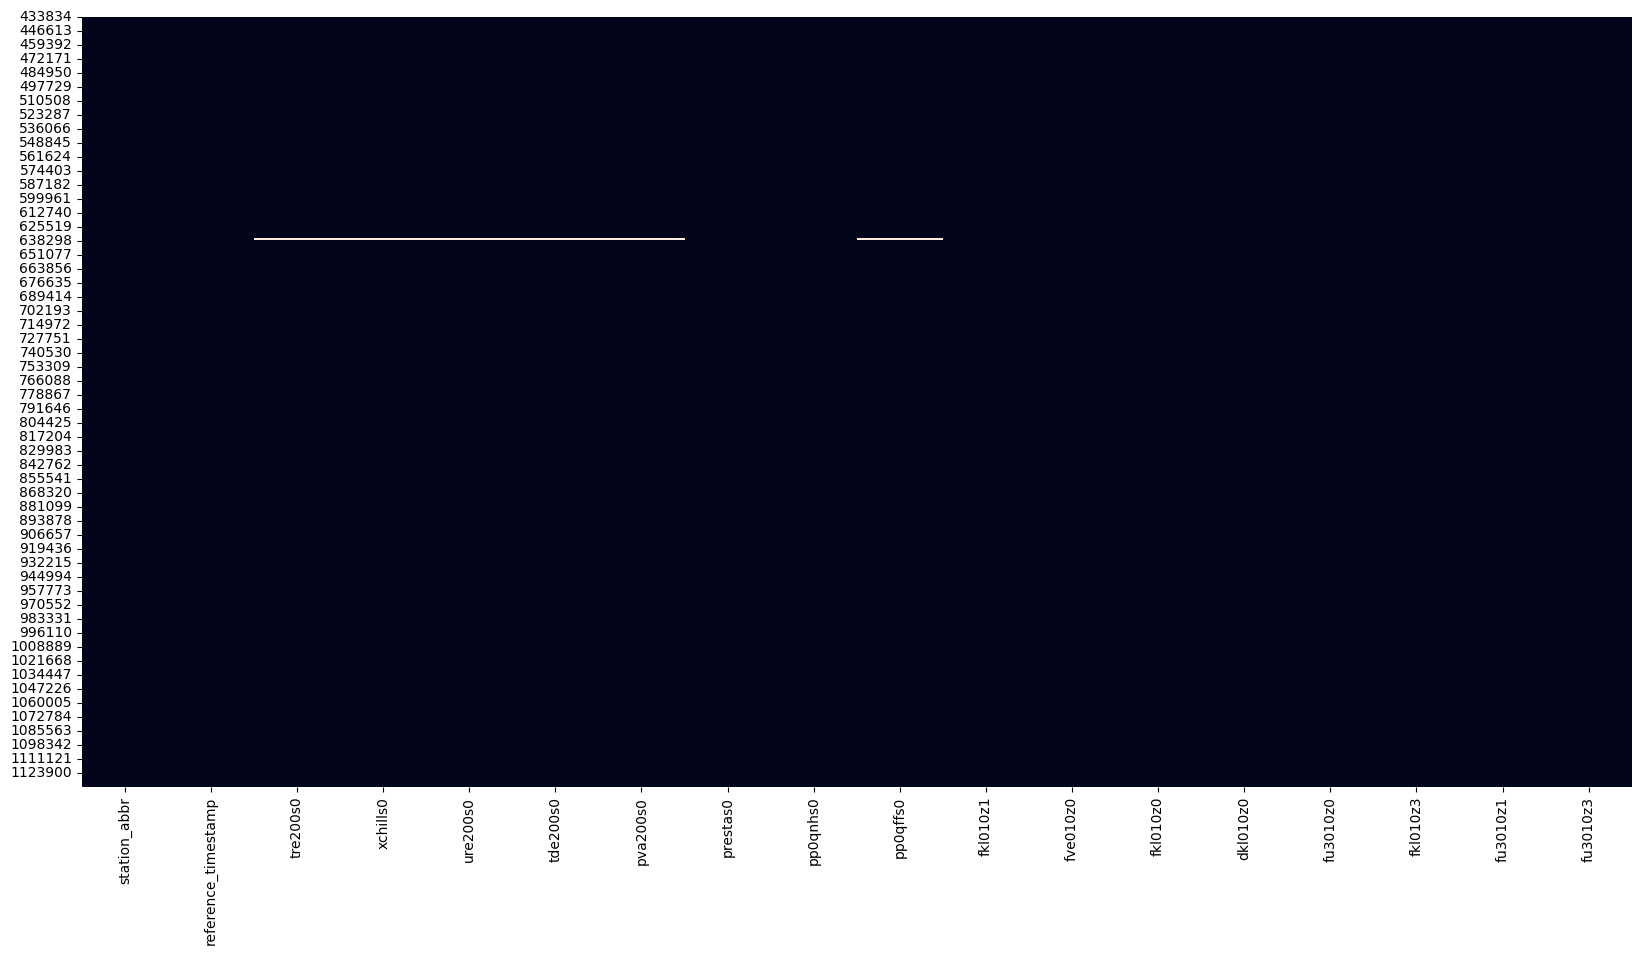

In [42]:
df['reference_timestamp'] = pd.to_datetime(df['reference_timestamp'], dayfirst=True)

date_limite = pd.Timestamp('2012-08-21 08:30:00')

# On RE-DÉFINIT le dataframe en ne gardant que les lignes STRICTEMENT SUPÉRIEURES ou ÉGALES
df_2012_2029 = df[df['reference_timestamp'] >= date_limite].copy()

# Vérification immédiate
print(f"Date de début réelle : {df_2012_2029['reference_timestamp'].min()}")
print(f"Nombre de lignes restantes : {len(df_2012_2029)}")

plt.figure(figsize=(20,10))
sns.heatmap(df_2012_2029.isna(), cbar=False)

### Renommage des colonnes

In [60]:
nouveau_noms_colonnes = {
    "station_abbr": "abr_station",  # station_abbreviation
    "reference_timestamp": "horodatage_référence",  # reference_timestamp
    "tre200s0": "température_air",  # Air temperature 2 m above ground; current value [cite: 1]
    "xchills0": "température_refroidissement_éolien",  # Chill temperature; current value [cite: 141]
    "ure200s0": "humidité",  # Relative air humidity 2 m above ground; current value [cite: 5, 6]
    "tde200s0": "point_de_rosée",  # Dew point 2 m above ground; current value [cite: 17]
    "pva200s0": "pression_vapeur",  # Vapour pressure 2 m above ground; current value [cite: 175, 176]
    "prestas0": "pression_barométrique_qfe",  # Atmospheric pressure at barometric altitude (QFE); current value [cite: 1]
    "pp0qnhs0": "pression_niveau_mer_standard_qnh",  # Atmospheric pressure reduced to sea level according to standard atmosphere (QNH); current value [cite: 168]
    "pp0qffs0": "pression_niveau_mer_réelle_qff",  # Atmospheric pressure reduced to sea level (QFF); current value [cite: 170]
    "fkl010z1": "rafale_1s_maximum_10min",  # Gust peak (one second); maximum in m/s [cite: 7]
    "fve010z0": "vitesse_vent_vectorielle_moyenne_10min",  # Wind speed vectoriel; ten minutes mean in m/s [cite: 18, 19]
    "fkl010z0": "vitesse_vent_scalaire_moyenne_10min",  # Wind speed scalar; ten minutes mean in m/s [cite: 21]
    "dkl010z0": "direction_du_vent_moyenne_10min",  # Wind direction; ten minutes mean [cite: 22]
    "fu3010z0": "vitesse_vent_moyenne_10min_kmh",  # Wind speed; ten minutes mean in km/h [cite: 191]
    "fkl010z3": "rafale_3s_maximum_10min",  # Gust peak (three seconds); maximum in m/s [cite: 216]
    "fu3010z1": "rafale_1s_maximum_kmh",  # Gust peak (one second); maximum in km/h [cite: 219]
    "fu3010z3": "rafale_3s_maximum_kmh",  # Gust peak (three seconds); maximum in km/h [cite: 239]
}

In [66]:
df.rename(columns=nouveau_noms_colonnes, inplace=True) # ? remplacement des anciens titres de colonne par des nouveaux
df.drop([
    "rafale_3s_maximum_10min",
    "rafale_1s_maximum_kmh",
    "vitesse_vent_vectorielle_moyenne_10min", 
    "vitesse_vent_scalaire_moyenne_10min", 
    "pression_niveau_mer_réelle_qff", 
    "pression_niveau_mer_standard_qnh",
    "pression_vapeur",
    "point_de_rosée",
    "température_refroidissement_éolien",
    "abr_station"], axis=1)

,horodatage_référence,température_air,humidité,pression_barométrique_qfe,rafale_1s_maximum_10min,direction_du_vent_moyenne_10min,vitesse_vent_moyenne_10min_kmh,rafale_3s_maximum_kmh
0,2004-02-01 00:00:00,NaN,NaN,NaN,2.8,149.0,6.8,NaN
1,2004-02-01 00:10:00,NaN,NaN,NaN,3.0,144.0,7.9,NaN
2,2004-02-01 00:20:00,NaN,NaN,NaN,4.0,140.0,8.6,NaN
3,2004-02-01 00:30:00,NaN,NaN,NaN,5.2,137.0,13.3,NaN
4,2004-02-01 00:40:00,NaN,NaN,NaN,4.7,148.0,11.5,NaN
...,...,...,...,...,...,...,...,...
1136642,2025-12-31 23:10:00,-1.5,79.2,977.3,2.5,123.0,7.6,9.0
1136643,2025-12-31 23:20:00,-1.7,82.9,977.1,2.3,125.0,6.1,7.9
1136644,2025-12-31 23:30:00,-2.0,85.2,977.1,1.9,141.0,4.7,6.8
1136645,2025-12-31 23:40:00,-2.2,85.3,977.1,1.8,135.0,4.7,6.5


In [68]:
df_2012_2029.rename(columns=nouveau_noms_colonnes, inplace=True) # ? remplacement des anciens titres de colonne par des nouveaux
df_2012_2029.drop([
    "rafale_3s_maximum_10min",
    "rafale_1s_maximum_kmh",
    "vitesse_vent_vectorielle_moyenne_10min", 
    "vitesse_vent_scalaire_moyenne_10min", 
    "pression_niveau_mer_réelle_qff", 
    "pression_niveau_mer_standard_qnh",
    "pression_vapeur",
    "point_de_rosée",
    "température_refroidissement_éolien",
    "abr_station"], axis=1)

,horodatage_référence,température_air,humidité,pression_barométrique_qfe,rafale_1s_maximum_10min,direction_du_vent_moyenne_10min,vitesse_vent_moyenne_10min_kmh,rafale_3s_maximum_kmh
433834,2012-08-21 08:30:00,24.1,NaN,976.6,1.5,304.0,4.0,NaN
433835,2012-08-21 08:40:00,24.2,NaN,976.5,2.1,313.0,5.0,NaN
433836,2012-08-21 08:50:00,24.3,NaN,976.5,1.4,319.0,3.6,NaN
433837,2012-08-21 09:00:00,24.2,NaN,976.5,1.5,326.0,4.0,NaN
433838,2012-08-21 09:10:00,24.2,NaN,976.4,1.7,312.0,4.7,NaN
...,...,...,...,...,...,...,...,...
1136642,2025-12-31 23:10:00,-1.5,79.2,977.3,2.5,123.0,7.6,9.0
1136643,2025-12-31 23:20:00,-1.7,82.9,977.1,2.3,125.0,6.1,7.9
1136644,2025-12-31 23:30:00,-2.0,85.2,977.1,1.9,141.0,4.7,6.8
1136645,2025-12-31 23:40:00,-2.2,85.3,977.1,1.8,135.0,4.7,6.5


### Transformation du .csv en .parquet

In [70]:
df.to_parquet('data/processed_windspeed.parquet', engine='pyarrow', index=False)

In [72]:
df_2012_2029.to_parquet('data/processed_windspeed_2012_2029.parquet', engine='pyarrow', index=False)